<img src="https://upload.wikimedia.org/wikipedia/commons/3/35/Uba_fiuba_ingenieria_logo.png" width="300" align="center">



# **Analisis de Series de Tiempo II**

# **Clase 4, Exploración de Series Multivariadas**

Importamos las librerias necesarias

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Fijamos las opciones de impresion para que las tablas se lean bien

In [ ]:
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)

### **A) Dataset Multivariado: Calidad del aire en Beijing**


Descargamos el dataset horario de contaminacion de Beijing (UCI, 2010-2014)

Este dataset contiene mediciones horarias de PM2.5 registradas en Beijing. Además, incluye datos meteorológicos obtenidos del Aeropuerto Internacional de Beijing Capital.

PM2.5 se refiere a las partículas finas en suspensión con un diámetro aerodinámico menor o igual a 2.5 micrómetros (µm). Debido a su reducido tamaño, estas partículas pueden penetrar profundamente en los pulmones e incluso ingresar al torrente sanguíneo, por lo que constituyen uno de los principales indicadores de la calidad del aire y representan un riesgo importante para la salud humana.

In [ ]:
url_aire = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pollution.csv"
aire = pd.read_csv(url_aire)

Construimos el indice temporal combinando las columnas de fecha y hora

In [ ]:
aire["fecha"] = pd.to_datetime(aire[["year", "month", "day", "hour"]])
aire = aire.set_index("fecha")

Renombramos las columnas relevantes al español para leer mejor los resultados

In [ ]:
aire = aire.rename(columns={
    "pm2.5": "pm25", # Concentracion de particulas finas (el target)
    "DEWP": "punto_rocio", # Punto de rocio en grados Celsius
    "TEMP": "temperatura", # Temperatura en grados Celsius
    "PRES": "presion", # Presion atmosferica en hPa
    "Iws": "viento", # Velocidad acumulada del viento
})

Seleccionamos el target y las cuatro covariables meteorologicas

In [ ]:
aire = aire[["pm25", "punto_rocio", "temperatura", "presion", "viento"]]

Contamos los valores faltantes: el sensor de PM2.5 se cayo muchas horas

In [ ]:
print(aire.isna().sum())

pm25           2067
punto_rocio       0
temperatura       0
presion           0
viento            0
dtype: int64


Describimos las variables para ver el problema de escalas heterogeneas

In [ ]:
print(aire.describe().loc[["mean", "std", "min", "max"]].round(1))

       pm25  punto_rocio  temperatura  presion  viento
mean   98.6          1.8         12.4   1016.4    23.9
std    92.1         14.4         12.2     10.3    50.0
min     0.0        -40.0        -19.0    991.0     0.4
max   994.0         28.0         42.0   1046.0   585.6


Calculamos la correlacion del target con cada covariable

In [ ]:
print(aire.corr()["pm25"].round(2))

pm25           1.00
punto_rocio    0.17
temperatura   -0.09
presion       -0.05
viento        -0.25
Name: pm25, dtype: float64


Calculamos la correlacion cruzada con retraso: el clima de hace 12h vs PM2.5 de ahora

In [ ]:
for col in ["punto_rocio", "temperatura", "presion", "viento"]:
    # Desplazamos la covariable 12 horas hacia adelante y correlacionamos
    corr_retraso = aire["pm25"].corr(aire[col].shift(12))
    print(f"  pm25(t) vs {col}(t-12): {corr_retraso:>6.2f}")

  pm25(t) vs punto_rocio(t-12):   0.08
  pm25(t) vs temperatura(t-12):  -0.05
  pm25(t) vs presion(t-12):   0.02
  pm25(t) vs viento(t-12):  -0.20


### **B) Dataset Panel: Desempleo por Industria en EEUU**


Descargamos el panel mensual de desempleo por industria (BLS, 2000-2010)

In [ ]:
url_panel = "https://raw.githubusercontent.com/vega/vega-datasets/main/data/unemployment-across-industries.json"
desempleo = pd.read_json(url_panel)

Pivoteamos el panel:
* Transformamos un DataFrame de formato largo (long format) a formato ancho (wide format), donde cada columna representa una serie temporal y cada fila un instante de tiempo.
* Cada fila es un mes, cada columna una industria

In [ ]:
panel = desempleo.pivot_table(index="date", columns="series", values="count")

Mostramos las dimensiones del panel: pocas observaciones, varias series

In [ ]:
print(f"Panel BLS: {panel.shape[0]} meses x {panel.shape[1]} industrias")

Panel BLS: 122 meses x 14 industrias


Ordenamos las industrias por su nivel medio para exponer el problema de escala

In [ ]:
escalas = panel.mean().sort_values()
print(escalas.round(0))

series
Mining and Extraction             32.0
Agriculture                      132.0
Information                      189.0
Transportation and Utilities     281.0
Other                            311.0
Self-employed                    322.0
Finance                          329.0
Government                       539.0
Education and Health             633.0
Construction                     868.0
Business services                910.0
Leisure and hospitality          994.0
Manufacturing                   1021.0
Wholesale and Retail Trade      1178.0
dtype: float64


Calculamos el ratio entre la industria mas grande y la mas chica

In [ ]:
print(f"Ratio de escalas (mayor / menor): {escalas.max() / escalas.min():.0f}x")

Ratio de escalas (mayor / menor): 36x


Medimos qué tan parecidas son las distintas industrias entre sí. Calculamos la correlación promedio entre todas las series temporales del panel.

In [ ]:
correlaciones = panel.corr()
mascara = ~np.eye(len(correlaciones), dtype=bool) #elimina la diagonal
print(f"Correlacion media entre industrias: {correlaciones.values[mascara].mean():.2f}")

Correlacion media entre industrias: 0.76


Un modelo global probablemente pueda aprovechar esos patrones compartidos

### **C) Visualización de la Estructura Compartida**

Creamos una figura con dos paneles para comparar niveles y dinamicas

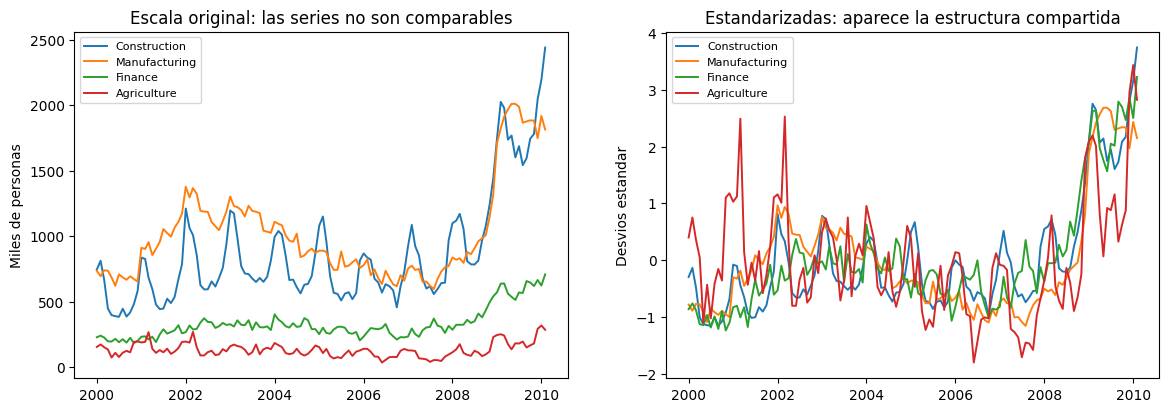

In [ ]:
fig, ejes = plt.subplots(1, 2, figsize=(14, 4.5))

# Graficamos cuatro industrias en su escala original
for ind in ["Construction", "Manufacturing", "Finance", "Agriculture"]:
    ejes[0].plot(panel.index, panel[ind], label=ind, linewidth=1.4)
ejes[0].set_title("Escala original: las series no son comparables")
ejes[0].set_ylabel("Miles de personas")
ejes[0].legend(fontsize=8)

# Graficamos las mismas industrias estandarizadas por serie (cada serie tiene media 0,
# desviación estándar 1)
for ind in ["Construction", "Manufacturing", "Finance", "Agriculture"]:
    z = (panel[ind] - panel[ind].mean()) / panel[ind].std()
    ejes[1].plot(panel.index, z, label=ind, linewidth=1.4)
ejes[1].set_title("Estandarizadas: aparece la estructura compartida")
ejes[1].set_ylabel("Desvios estandar")
ejes[1].legend(fontsize=8)

Muchos modelos de Deep Learning, especialmente los modelos globales, aprenden mejor cuando todas las variables tienen escalas similares. De lo contrario, las series con valores más grandes dominan el entrenamiento y el modelo presta menos atención a las series pequeñas.